In [1]:
import os

ROOT = '/kaggle/input/datasets/marciocure/sabia-brazilian-bird-acoustics-dataset'
os.listdir(path=ROOT)

['Habia_rubica',
 'Mionectes_rufiventris',
 'Cyanocorax_chrysops',
 'Philydor_atricapillus',
 'Drymophila_ochropyga',
 'Anabazenops_fuscus',
 'Pitangus_sulphuratus',
 'Pionus_maximiliani',
 'Hemitriccus_furcatus',
 'Legatus_leucophaius',
 'Pyriglena_leucoptera',
 'Patagioenas_plumbea',
 'Trichothraupis_melanops',
 'Zonotrichia_capensis',
 'Elaenia_sordida',
 'Eleoscytalopus_indigoticus',
 'Myiozetetes_similis',
 'Laterallus_melanophaius',
 'Saltator_similis',
 'Phacellodomus_ferrugineigula',
 'Campephilus_robustus',
 'Pachyramphus_polychopterus',
 'Coereba_flaveola',
 'Ramphodon_naevius',
 'Dendroma_rufa',
 'Piculus_aurulentus',
 'Formicarius_colma',
 'Biatas_nigropectus',
 'Cnemotriccus_fuscatus',
 'Todirostrum_poliocephalum',
 'Carpornis_cucullata',
 'Dysithamnus_mentalis',
 'Phyllomyias_burmeisteri',
 'Dendrocolaptes_platyrostris',
 'Phylloscartes_ventralis',
 'Ilicura_militaris',
 'Myiothlypis_rivularis',
 'Merulaxis_ater',
 'Vanellus_chilensis',
 'Nyctidromus_albicollis',
 'Thamno

We have a lot of classes, and we want to use image embeddings from ResNeXt for EDA and classification. Let's add some code to get them for us.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 175MB/s]


Let's load up our data. We'll start with a small sample because we're in a hurry.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

N = 10
THUMBNAIL_SIZE = (48, 48)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except: 
        print(filename)
        return None


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    input_files = list(iglob(pathname=arg))
    input_files = [item for item in input_files if item.endswith('.jpg') or item.endswith('.png')]
    # input_files = [item for item in input_files if basename(item) not in IGNORE]
    input_files = input_files[:N]
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'])
        for index, input_file in enumerate(tqdm.tqdm(desc='images', iterable=input_files)) ]
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(ROOT + '/*') if isdir(folder) }
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in train_dict.items()]))
print('done in {}'.format(arrow.now() - time_start))

images: 100%|██████████| 10/10 [00:01<00:00,  6.83it/s]


done in 0:04:09.765903


Are our classes balanced?

In [4]:
train_df['tag'].value_counts().to_frame().T

tag,Habia_rubica,Mionectes_rufiventris,Cyanocorax_chrysops,Philydor_atricapillus,Drymophila_ochropyga,Anabazenops_fuscus,Pitangus_sulphuratus,Pionus_maximiliani,Hemitriccus_furcatus,Legatus_leucophaius,...,Xiphorhynchus_fuscus,Arremon_semitorquatus,Haplospiza_unicolor,Grallaria_varia,Mackenziaena_severa,Campylorhamphus_falcularius,Penelope_obscura,Drymophila_malura,Sporophila_frontalis,Elaenia_mesoleuca
count,10,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,10


Let's add x/y coordinates based on our image embeddings using TSNE.

In [5]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1720 samples in 0.008s...
[t-SNE] Computed neighbors for 1720 samples in 0.347s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1720
[t-SNE] Computed conditional probabilities for sample 1720 / 1720
[t-SNE] Mean sigma: 2.868984
[t-SNE] KL divergence after 250 iterations with early exaggeration: 78.406799
[t-SNE] KL divergence after 1000 iterations: 1.923247


Let's make a static plot using a sample of our data.

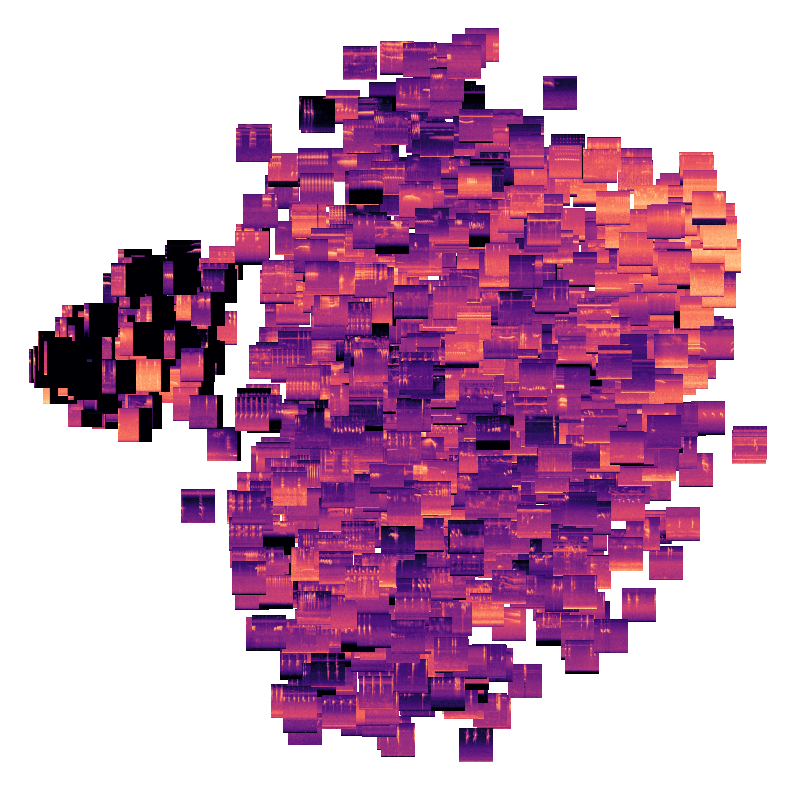

In [6]:
import base64
import io
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image

# we recycled some PNG encoding code above, and we need to postprocess it for using with matplotlib
train_df['PNG'] = train_df['png'].str.replace('^data:image/png;base64,', '', regex=True)
plot_df = train_df.sample(n=1000, random_state=2026)

fig, ax = plt.subplots(figsize=(10, 10))

for index, row in plot_df.iterrows():
    img_bytes = base64.b64decode(row["PNG"])
    img = Image.open(io.BytesIO(img_bytes))
    imagebox = OffsetImage(img, zoom=0.5)
    ab = AnnotationBbox(imagebox, (row["x"], row["y"]), frameon=False, pad=0)
    ax.add_artist(ab)
ax.scatter(plot_df["x"], plot_df["y"], alpha=0)
ax.axis('off')
plt.show()

We mostly have two clusters: one with dark regions and one without. Let's make an interactive plot.

In [7]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: birdsong waveforms', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=8, color=mapper)
show(plot_figure)

Loading BokehJS ...

We don't see a lot of clustering aligned with our classes. Let's build a model and see what we get. We should have modest expectations regarding model accuracy.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_df['value'].apply(pd.Series), train_df['tag'], test_size=0.25, random_state=2026, stratify=train_df['tag'])
logreg = LogisticRegression(max_iter=10000, tol=1e-12).fit(X_train, y_train)
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=y_test, y_pred=logreg.predict(X=X_test))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=y_test, y_pred=logreg.predict(X=X_test))))
print(classification_report(y_true=y_test, y_pred=logreg.predict(X=X_test), zero_division=0.0))

model fit in 1401 iterations
accuracy: 0.2558
f1: 0.2476
                              precision    recall  f1-score   support

          Anabazenops_fuscus       0.00      0.00      0.00         2
           Aramides_saracura       0.25      0.33      0.29         3
       Arremon_semitorquatus       0.00      0.00      0.00         3
           Asthenes_moreirae       0.20      0.33      0.25         3
          Attila_phoenicurus       0.00      0.00      0.00         2
                Attila_rufus       0.00      0.00      0.00         2
    Automolus_leucophthalmus       0.00      0.00      0.00         2
  Baryphthengus_ruficapillus       1.00      0.67      0.80         3
    Basileuterus_culicivorus       0.00      0.00      0.00         2
              Batara_cinerea       0.00      0.00      0.00         2
          Biatas_nigropectus       0.00      0.00      0.00         2
           Brotogeris_tirica       0.00      0.00      0.00         3
        Cacicus_chrysopterus    

Not surprisingly our class f1 scores are mostly awful. Maybe they'll improve with more data. Let's look at our model probabilities.

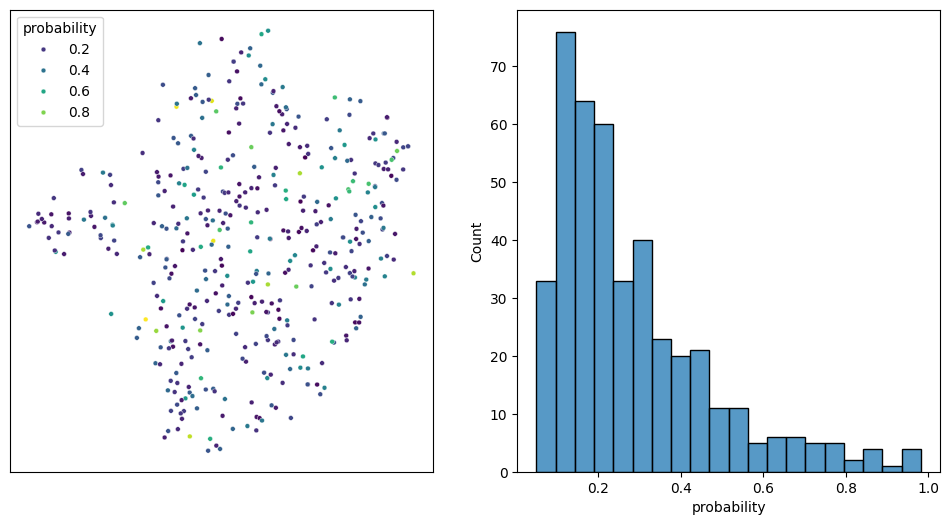

In [9]:
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = train_df.iloc[X_test.index][['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=X_test), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=12)
ax[0].set(xlabel=None) 
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)
fig.show()

Our model probabilities are mostly poor too.